In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats

In [4]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,classification_report

import warnings
import joblib

In [5]:
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')
%matplotlib inline

In [6]:
df = pd.read_csv("loan_prediction.csv")
df
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [8]:
df.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [9]:
(df.isnull().sum()/len(df)*100)

Loan_ID              0.000000
Gender               2.997275
Married              0.000000
Dependents           2.724796
Education            0.000000
Self_Employed        6.267030
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           1.362398
Loan_Amount_Term     1.634877
Credit_History       7.901907
Property_Area        0.000000
dtype: float64

In [10]:
print("==== Data Information===")
print(df.info())
print("==== Mission values ===")
print(df.isnull().sum())

df['Gender'] = df['Gender'].fillna('unknown')
df['Dependents'] = df['Dependents'].fillna('unknown')
df['Self_Employed '] = df['Self_Employed'].fillna('unknown')
df['Credit_History '] = df['Credit_History'].fillna('unknown')

==== Data Information===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB
None
==== Mission values ===
Loan_ID               0
Gender               11
Married               0
Dependents           10
Education 

In [11]:
def descriptive_stats(data):

    if isinstance(data,pd.Series):
        data = data.values
    stats_dict = {
        'count': len(data),
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data,ddof=1),
        'min': np.min(data),
        'max': np.max(data),
        'q1': np.percentile(data, 25),
        'q2': np.percentile(data, 75),
        'q3': np.percentile(data, 75),
        'iqr': np.percentile(data,75) - percentile(data,25),
        'skewness':stats.skew(data),
        'kurtosis':stats.kurtosis(data)
    }
    return pd.Series(stats_dict)

In [12]:
print(df.describe())

       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       367.000000         367.000000  362.000000        361.000000   
mean       4805.599455        1569.577657  136.132597        342.537396   
std        4910.685399        2334.232099   61.366652         65.156643   
min           0.000000           0.000000   28.000000          6.000000   
25%        2864.000000           0.000000  100.250000        360.000000   
50%        3786.000000        1025.000000  125.000000        360.000000   
75%        5060.000000        2430.500000  158.000000        360.000000   
max       72529.000000       24000.000000  550.000000        480.000000   

       Credit_History  
count      338.000000  
mean         0.825444  
std          0.380150  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


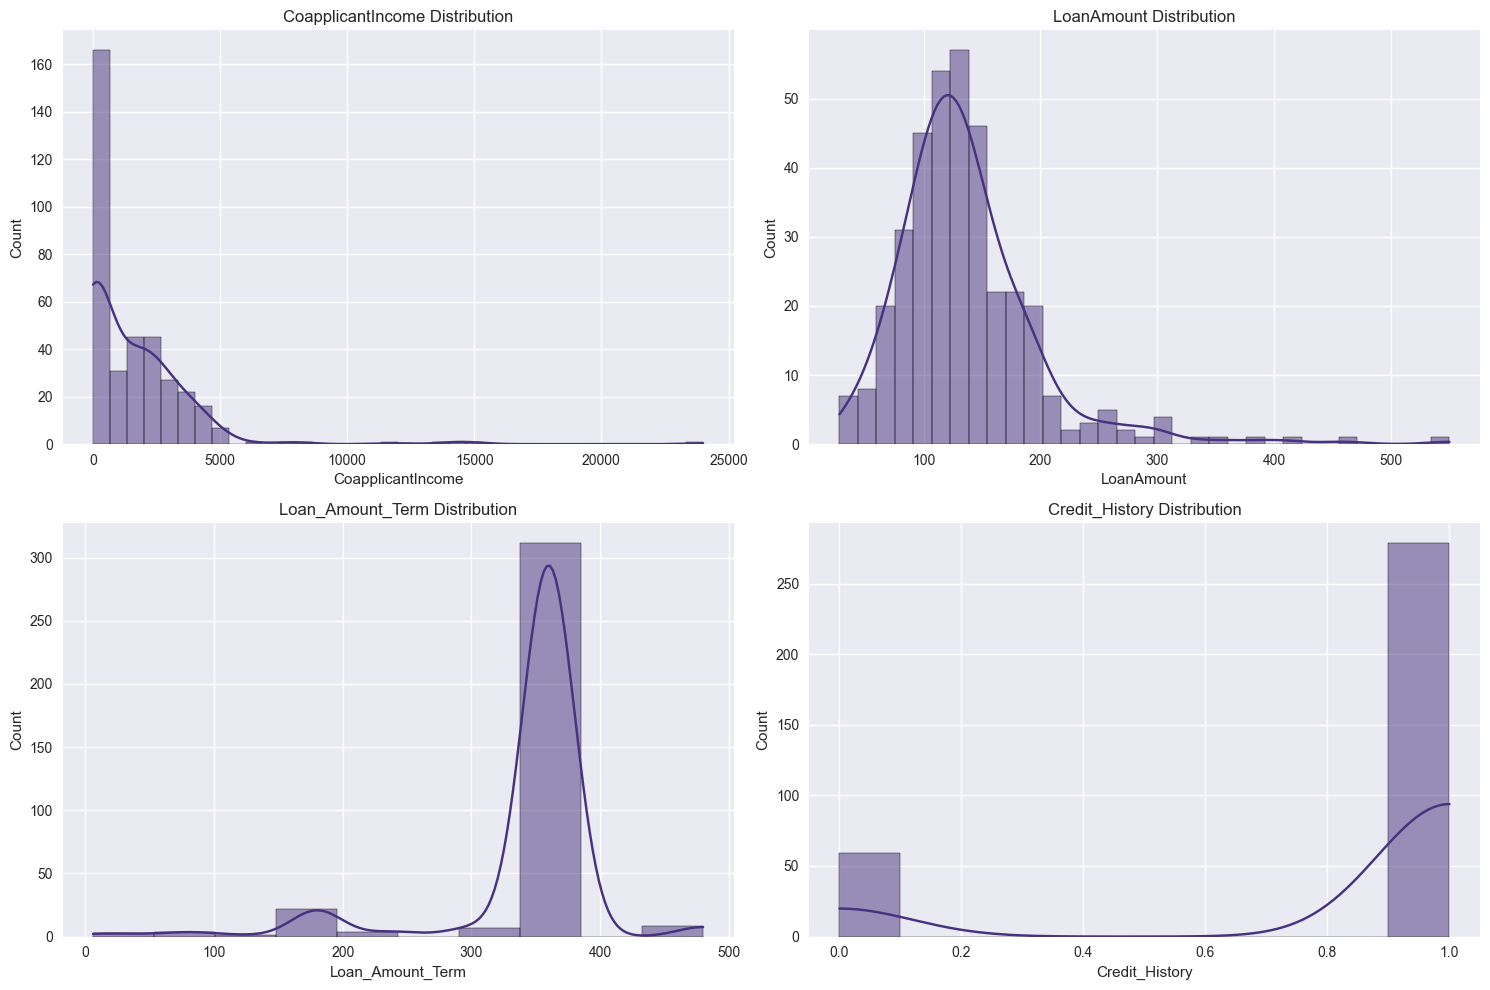

In [13]:
fig, axes = plt.subplots(2,2, figsize=(15,10))
sns.histplot(df['CoapplicantIncome'],kde=True, ax=axes[0,0]).set_title('CoapplicantIncome Distribution')
sns.histplot(df['LoanAmount'],kde=True, ax=axes[0,1]).set_title('LoanAmount Distribution')
sns.histplot(df['Loan_Amount_Term'],kde=True,ax=axes[1,0]).set_title('Loan_Amount_Term Distribution')
sns.histplot(df['Credit_History'],kde=True, ax=axes[1,1]).set_title('Credit_History Distribution')
plt.tight_layout()
plt.show()

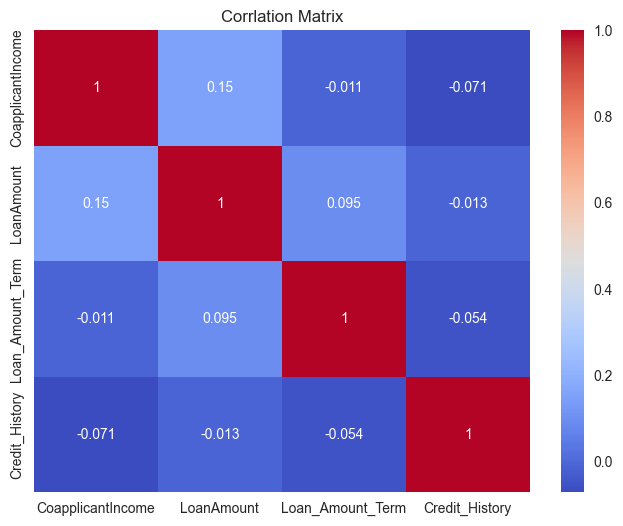

In [14]:
plt.figure(figsize=(8,6))
numeric_df=df[['CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']]
sns.heatmap(numeric_df.corr(),annot=True, cmap='coolwarm')
plt.title('Corrlation Matrix')
plt.show()

In [15]:
#T-Test
male_age = df[df['Gender'] =='Male']['CoapplicantIncome']
Female_age = df[df['Gender'] =='Female']['CoapplicantIncome']
t_stats,p_val = ttest_ind(male_age,Female_age)
print (f"T-statstic:{t_stats:.4f},P-value:{p_val:.4f}")

T-statstic:1.5905,P-value:0.1126


In [16]:
groups = [group['Credit_History'].values for name ,group in df.groupby('Self_Employed')]
f_stat,p_val=f_oneway(*groups)
print (f"F-statstic:{f_stat:.4f},P-value:{p_val:.4f}")

df.head()

F-statstic:nan,P-value:nan


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Self_Employed,Credit_History
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban,No,1.0
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban,No,1.0
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban,No,1.0
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban,No,unknown
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban,No,1.0


In [17]:
contingency = pd.crosstab(df['Loan_Amount_Term'],df['Property_Area'])
chi2, p, dof,expected = chi2_contingency(contingency)
print (f"Chi_square:{chi2:.4f},P-value:{p_val:.4f}")

Chi_square:19.3335,P-value:nan


In [18]:
X = pd.get_dummies(df.drop(['Loan_ID','Credit_History','Loan_Amount_Term'],axis=1),drop_first=True)
y = df['Loan_Amount_Term']

In [19]:
print(y.isnull().sum())
print(y[y.isnull()])


6
45    NaN
48    NaN
117   NaN
129   NaN
184   NaN
214   NaN
Name: Loan_Amount_Term, dtype: float64


In [20]:
print("NaN values in y:", y.isna().sum())

NaN values in y: 6


In [21]:
mask = y.notna()

X = X[mask]
y = y[mask]

In [22]:
print(X.shape)
print(y.shape)
print(y.isna().sum())

(361, 18)
(361,)
0


In [23]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
from sklearn.metrics import accuracy_score

# Train the model
clf_model.fit(X_train, y_train)

# Make predictions
y_pred = clf_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")



Accuracy: 0.8767
Accuracy Percentage: 87.67%


In [30]:
print("Random Forest:",clf_model)

Random Forest: RandomForestClassifier(random_state=42)


In [31]:
joblib.dump(clf_model, 'recurrence_classifier_model.pkl')
print("✅ Model saved as 'recurrence_classifier_model.pkl'")

✅ Model saved as 'recurrence_classifier_model.pkl'
